In [1]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys 
sys.path.append("../")

from checkpoint import CheckPoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
st_1 = CheckPoint.from_pt(path="../models/copy_batching_experiments/MLC_batchalph_dallstudy1_copy_perm20_nep20.pt")
st_2 = CheckPoint.from_pt(path="../models/study_examples/MLC_batchstudy_alph_dallstudy2_copy_perm20_nep20.pt")
st_3 = CheckPoint.from_pt(path="../models/study_examples/MLC_batchstudy_alph_dallstudy3_copy_perm20_nep20.pt")
st_4 = CheckPoint.from_pt(path="../models/study_examples/MLC_batchstudy_alph_dallstudy4_copy_perm20_nep20.pt")
st_5 = CheckPoint.from_pt(path="../models/study_examples/MLC_batchstudy_alph_dallstudy5_copy_perm20_nep20.pt")

all_training_runs = [st_1, st_2, st_3, st_4, st_5]

In [3]:
val_accs = pd.DataFrame()
for n, cp in enumerate(all_training_runs, start=1):
    df = pd.DataFrame(cp.val_acc_hist)
    df["n_study"] = n
    val_accs = pd.concat([val_accs, df])

### Performance by number of study examples

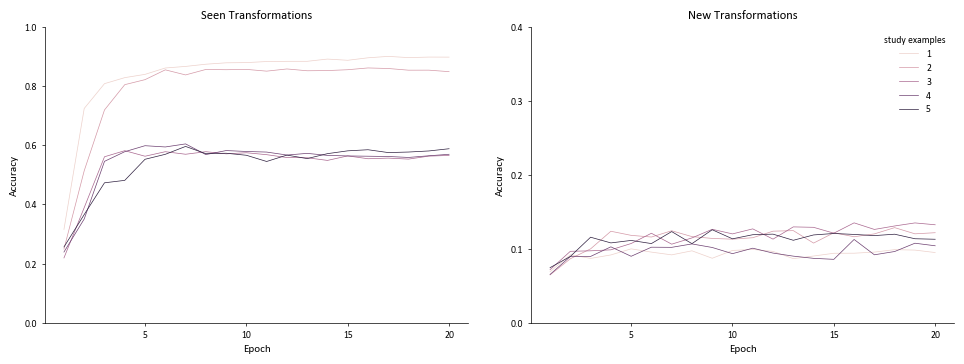

In [4]:
# Figure 1 Appendix
plt.style.use("./figures_stylesheet.mplstyle")
fig, ax = plt.subplots(1,2, figsize=(10,4))
_ = sns.lineplot(val_accs, x="epoch", y="in", hue="n_study", ax=ax[0])
_ = ax[0].set_xlabel("Epoch")
_ = ax[0].set_ylabel("Accuracy")
_ = ax[0].set_xticks([5,10,15,20])
_ = ax[0].set_ylim((0,1))
_ = ax[0].set_title("Seen Transformations")

_ = ax[0].legend().remove()
_ = sns.lineplot(val_accs, x="epoch", y="out-of", hue="n_study", ax=ax[1])
_ = ax[1].legend(title="study examples", loc='upper right')
_ = ax[1].set_xlabel("Epoch")
_ = ax[1].set_ylabel("Accuracy")
_ = ax[1].set_ylim((0,0.3))
_ = ax[1].set_xticks([5,10,15,20])
_ = ax[1].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
_ = ax[1].set_title("New Transformations")

_ = fig.tight_layout(pad=2)

In [5]:
# Table 1 Appendix
print("Final Overall Val. Accuracies")
overall_accs = val_accs[val_accs["epoch"]==20][["n_study", "overall"]]
overall_accs

Final Overall Val. Accuracies


,n_study,overall
19,1,0.624714
19,2,0.536501
19,3,0.361684
19,4,0.351655
19,5,0.371229


### Further Analysis 

In [6]:
from analyses.intervenor import TransformerIntervenor

c:\Users\13579681\AppData\Local\anaconda3\envs\mlc-ls\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
test_dl = st_2.load_dataloaders("../data/letter-string-analogies/all_transformations_study2_copy_perm20", use_datasets=["test"])[0]

Loaded following dataloaders:
test dataloader (n=45,875)


In [8]:
model = st_2.load_model(verbose=False)

In [20]:
data = torch.tensor([29], dtype=torch.long)

embedded_int = model.input_embedding(data)
embedded_int.shape

torch.Size([1, 128])

In [15]:
embedded_int

tensor([[ 0.1598, -0.1600, -0.3056, -0.0485,  0.0160, -0.1025,  0.0652,  0.0294,
         -0.1971,  0.0678, -0.3107, -0.4131, -0.5487, -0.4058, -0.4569,  0.4755,
          0.1899,  0.6393, -0.0771,  0.0435,  0.6421,  0.5116,  0.4312, -0.6820,
          0.2006, -0.3796, -0.3973, -0.2463, -0.4580,  0.0701, -0.3677, -0.0400,
          0.1119,  0.1672, -0.5367, -0.2311,  0.3833,  0.4721, -0.5184,  0.7015,
         -0.0837,  0.7240,  0.0660,  1.1255, -0.3590, -0.3410, -0.4361, -0.5677,
         -0.2237,  0.4529,  0.2554, -0.0229,  0.0852, -0.1372, -0.6706, -0.3783,
         -0.1796, -0.0167, -0.2102, -0.2584, -0.1734, -0.0425, -0.2764, -0.5311,
          0.1861, -0.5501,  0.0524, -0.7555,  0.3052, -0.8883,  0.0890, -0.7742,
         -0.2992, -0.7939,  0.3216, -0.0685,  0.4878, -0.6630,  0.3655, -0.2442,
          0.4948, -0.4215, -0.3073, -0.9298, -0.5545, -0.3639,  0.2915, -0.2816,
         -0.0293, -0.9336, -0.0290, -0.5095, -0.5076, -0.5230, -0.4770, -0.6316,
          0.4100, -0.3244, -

In [36]:
batch = next(iter(test_dl))

In [37]:
inter = TransformerIntervenor(model)
inter.run_and_save(batch)